# Task 1 — Inner Workings of ResNet-152

Imports

In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

if torch.backends.mps.is_available():
    device=torch.device("mps")
else:
    device=torch.device("cpu")
print(device)

mps


In [2]:
weights=models.ResNet152_Weights.DEFAULT
print(weights.transforms())

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [3]:
transform=weights.transforms()
training_set=datasets.CIFAR10(root="../data",train=True,
                             download=True,transform=transform)
testing_set=datasets.CIFAR10(root="../data",train=False,
                            download=True,transform=transform)
training_loader=DataLoader(training_set,batch_size=32,shuffle=True)
testing_loader=DataLoader(testing_set,batch_size=32,shuffle=False)

In [ ]:
model=models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
for parameter in model.parameters():
    parameter.requires_grad=False

features_count=model.fc.in_features
model.fc=nn.Linear(features_count,10)
model=model.to(device)

In [ ]:
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.fc.parameters(),lr=0.001)

epochs=3
training_losses=[]
validation_losses=[]

for epoch in range(epochs):
    #training
    model.train()
    running_loss=0.0
    for images,labels in training_loader:
        images,labels=images.to(device),labels.to(device)
        optimizer.zero_grad()
        outputs=model(images)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss=running_loss+loss.item()
    training_losses.append(running_loss/len(training_loader))

    #validation
    model.eval()
    validation_loss = 0.0
    with torch.no_grad():
        for images,labels in testing_loader:
            images,labels=images.to(device),labels.to(device)
            outputs=model(images)
            loss=criterion(outputs, labels)
            validation_loss=validation_loss+loss.item()
    validation_losses.append(validation_loss/len(testing_loader))

    print("Epoch",epoch+1)
    print("training: ",training_losses[-1])
    print("validation: ",validation_losses[-1])

Epoch 1
training:  0.6856696523501945
validation:  0.5292280357295331
Epoch 2
training:  0.517494979847797
validation:  0.4771308452367021
Epoch 3
training:  0.4784386472458345
validation:  0.49294413002535176


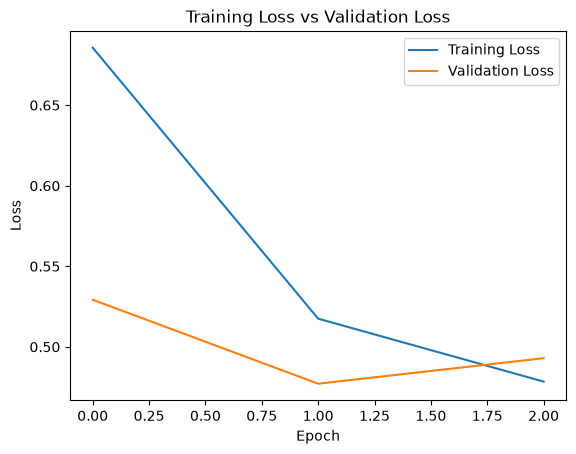

In [6]:
plt.plot(training_losses,label="Training Loss")
plt.plot(validation_losses,label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()
plt.savefig("baseline_loss.png")
plt.show()